# NV-to-lab calibration from fixed left ODMR lines: response matrix and Schloss-style \(A\)

This notebook rewrites the previous geometry notebook around the quantity used by **Schloss et al.*

## What this notebook computes

1. The **measured displacement-response matrix**
\[
R_{\mathrm{disp}}=\frac{\partial \boldsymbol{\nu}_{\mathrm{left}}}{\partial \mathbf r},
\]
where \(\boldsymbol{\nu}_{\mathrm{left}}\) contains the four **left-side** ODMR line centers and \(\mathbf r=(x,y,z)\) is the magnet displacement in the lab frame.


## Fixed dip-to-axis assignment used here

From your experimental knowledge of the [100]-cut sample and the spectra:

- outermost left dip \(\rightarrow d3\)
- second left dip \(\rightarrow d2\)
- third left dip \(\rightarrow d4\)
- left dip closest to the center \(\rightarrow d1\)

So the left-line order throughout the notebook is
\[
[d3,\ d2,\ d4,\ d1].
\]

## Theory used

For each NV orientation \(i\), we model the electron-spin Hamiltonian as
\[
H_i/h = (D+M_{z,i})S_z^2 + \gamma_e\,\mathbf B_i\cdot \mathbf S,
\]
where:

- \(D\) is the zero-field splitting,
- \(M_{z,i}\) is the fitted axial shift of orientation \(i\),
- \(\mathbf B_i\) is the lab magnetic field expressed in the local NV frame,
- \(\gamma_e \approx 28.02495164\,\mathrm{MHz/mT}\).

We then diagonalize the spin-1 Hamiltonian numerically and use finite differences to compute
\[
A_{ij}=\frac{\partial \nu_i}{\partial B_j}.
\]

This follows the **Hamiltonian linearization strategy of Schloss et al.**, where the resonance frequencies are linearized around the measured operating point to form the \(4\times3\) matrix \(A\).

### References
- J. M. Schloss *et al.*, **Simultaneous Broadband Vector Magnetometry Using Solid-State Spins**, *Phys. Rev. Applied* **10**, 034044 (2018).  
- J. F. Barry *et al.*, **Sensitivity optimization for NV-diamond magnetometry**, *Rev. Mod. Phys.* **92**, 015004 (2020).  
- D. Lönard *et al.*, **Limits of absolute vector magnetometry with NV centers in diamond** (2025/2026).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from scipy.stats import linregress
from scipy.optimize import least_squares

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

GAMMA_E_MHZ_PER_MT = 28.02495164
LEFT_DIP_ORDER = ["d3", "d2", "d4", "d1"]  # outermost -> innermost on left side

OUTDIR = Path("./outputs")
OUTDIR.mkdir(exist_ok=True)


## Data source

The notebook can work in either of two ways:

1. **Preferred for this notebook:** read a single run-summary CSV if you already exported one.
2. Otherwise, reconstruct the same summary table directly from the existing folder structure:
   - `../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along X/...`
   - `../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along Y/...`
   - `../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along Z/...`

The notebook keeps the same folder access logic as your current version.


In [2]:
SUMMARY_CSV = Path("./summary_from_fits.csv")  # optional convenience file
ROOT = Path("../fitting_odmr/batch_fit_outputs_lorentzian")

VARIATION_TO_AXIS = {
    "Variation Along X": "x",
    "Variation Along Y": "y",
    "Variation Along Z": "z",
}

def parse_offset_mm(name: str) -> float:
    name = str(name).strip().replace(" ", "")
    if name in {"0cm", "0cm-0.0mm", "0cm+0.0mm", "6.8cm-0.0mm"}:
        return 0.0
    m = re.search(r'([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))
    m = re.search(r'0cm([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))
    m = re.search(r'6\.8cm([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))
    raise ValueError(f"Could not parse displacement from folder name: {name}")

def build_summary_from_root(root: Path) -> pd.DataFrame:
    rows = []

    for variation in VARIATION_TO_AXIS:
        variation_dir = root / variation
        if not variation_dir.exists():
            print(f"Missing folder: {variation_dir}")
            continue

        for run_dir in sorted([p for p in variation_dir.iterdir() if p.is_dir()]):
            pair_csv = run_dir / "paired_dips.csv"
            if not pair_csv.exists():
                print(f"Missing paired_dips.csv in {run_dir}")
                continue

            d = pd.read_csv(pair_csv).sort_values("pair_id").reset_index(drop=True)
            if len(d) != 4:
                print(f"Skipping {run_dir}: expected 4 pairs, got {len(d)}")
                continue

            row = {
                "variation": variation,
                "run_name": run_dir.name,
                "offset_mm": parse_offset_mm(run_dir.name),
                "D_eff_GHz": float(d["D_eff_GHz"].iloc[0]),
            }

            # optional metadata if available
            meta_json = run_dir / "fit_metadata.json"
            if meta_json.exists():
                import json
                meta = json.load(open(meta_json))
                for key in ["delta_hf_MHz", "lorentz_fwhm_MHz", "global_rms"]:
                    if key in meta:
                        row[key] = meta[key]

            # four left/right pair descriptors
            for pair_id in [1, 2, 3, 4]:
                sub = d[d["pair_id"] == pair_id].iloc[0]
                row[f"pair_{pair_id}_left_x1_GHz"] = float(sub["left_center_x1_GHz"])
                row[f"pair_{pair_id}_right_x1_GHz"] = float(sub["right_center_x1_GHz"])
                row[f"pair_{pair_id}_splitting_MHz"] = float(sub["splitting_MHz"])
                row[f"pair_{pair_id}_center_minus_D_eff_MHz"] = float(sub["pair_center_minus_D_eff_MHz"])

            rows.append(row)

    if not rows:
        raise FileNotFoundError(
            "No summary rows could be reconstructed. Either place summary_from_fits.csv next to this notebook "
            "or ensure the fitting output folders exist."
        )

    return pd.DataFrame(rows).sort_values(["variation", "offset_mm"]).reset_index(drop=True)

if SUMMARY_CSV.exists():
    summary_df = pd.read_csv(SUMMARY_CSV)
    print(f"Loaded summary CSV: {SUMMARY_CSV.resolve()}")
else:
    summary_df = build_summary_from_root(ROOT)
    print(f"Reconstructed summary table from: {ROOT.resolve()}")

summary_df["lab_axis"] = summary_df["variation"].map(VARIATION_TO_AXIS)
display(summary_df.head())
print("Rows loaded:", len(summary_df))

Reconstructed summary table from: /home/vita/projects/NV_sensing/fitting_odmr/batch_fit_outputs_lorentzian


,variation,run_name,offset_mm,D_eff_GHz,delta_hf_MHz,lorentz_fwhm_MHz,global_rms,pair_1_left_x1_GHz,pair_1_right_x1_GHz,pair_1_splitting_MHz,pair_1_center_minus_D_eff_MHz,pair_2_left_x1_GHz,pair_2_right_x1_GHz,pair_2_splitting_MHz,pair_2_center_minus_D_eff_MHz,pair_3_left_x1_GHz,pair_3_right_x1_GHz,pair_3_splitting_MHz,pair_3_center_minus_D_eff_MHz,pair_4_left_x1_GHz,pair_4_right_x1_GHz,pair_4_splitting_MHz,pair_4_center_minus_D_eff_MHz,lab_axis
0,Variation Along X,0cm-0.4mm,-0.4,2.871576,2.199619,1.533325,0.000643,2.807770,2.933508,125.738095,-0.936995,2.818928,2.923713,104.785094,-0.255599,2.835220,2.908747,73.526805,0.407387,2.846094,2.898628,52.534524,0.785207,x
1,Variation Along X,0cm-0.3mm,-0.3,2.871544,2.237182,1.579573,0.000729,2.808500,2.932712,124.211408,-0.938357,2.819427,2.923169,103.741528,-0.246403,2.835074,2.908740,73.666087,0.362643,2.845667,2.899066,53.399657,0.822117,x
2,Variation Along X,0cm-0.2mm,-0.2,2.871539,2.188336,1.482833,0.000719,2.809269,2.932084,122.814939,-0.863177,2.819939,2.922639,102.700289,-0.250149,2.834804,2.909024,74.220529,0.374400,2.845249,2.899307,54.058116,0.738926,x
3,Variation Along X,0cm-0.1mm,-0.1,2.871489,2.192951,1.504535,0.000550,2.809967,2.931334,121.366230,-0.838336,2.820412,2.922067,101.655332,-0.249408,2.834685,2.908968,74.283802,0.337753,2.844775,2.899702,54.927207,0.749991,x
4,Variation Along X,0cm-0.0mm,0.0,2.871453,2.218733,1.546208,0.000725,2.810709,2.930545,119.836066,-0.825603,2.820885,2.921594,100.708983,-0.212674,2.834467,2.909126,74.658799,0.343731,2.844376,2.899918,55.541525,0.694546,x


Rows loaded: 16


## Build the four left-side line traces

We now switch from pair splittings to the four selected **left** ODMR line centers.  
For every run, the pair-to-axis assignment is fixed by your experimental knowledge:
\[
\text{pair 1}\to d3,\quad
\text{pair 2}\to d2,\quad
\text{pair 3}\to d4,\quad
\text{pair 4}\to d1.
\]

This is the key change relative to the old notebook.

The frequency shifts are defined relative to the zero-displacement reference **within the same scan direction**:
\[
\Delta \nu_i(\Delta r_j)=\nu_i(\Delta r_j)-\nu_i(0).
\]


In [3]:
PAIR_TO_NV = {1: "d3", 2: "d2", 3: "d4", 4: "d1"}

left_rows = []
for _, row in summary_df.iterrows():
    for pair_id in [1, 2, 3, 4]:
        left_rows.append({
            "variation": row["variation"],
            "lab_axis": row["lab_axis"],
            "run_name": row["run_name"],
            "offset_mm": float(row["offset_mm"]),
            "pair_id": pair_id,
            "nv_axis": PAIR_TO_NV[pair_id],
            "nu_left_GHz": float(row[f"pair_{pair_id}_left_x1_GHz"]),
            "nu_right_GHz": float(row[f"pair_{pair_id}_right_x1_GHz"]),
            "splitting_MHz": float(row[f"pair_{pair_id}_splitting_MHz"]),
            "pair_center_minus_D_eff_MHz": float(row[f"pair_{pair_id}_center_minus_D_eff_MHz"]),
            "D_eff_GHz": float(row["D_eff_GHz"]),
        })

left_lines_long = pd.DataFrame(left_rows)
left_lines_long["nu_left_MHz"] = 1e3 * left_lines_long["nu_left_GHz"]
left_lines_long["nu_right_MHz"] = 1e3 * left_lines_long["nu_right_GHz"]

zero_ref = (
    left_lines_long[np.isclose(left_lines_long["offset_mm"], 0.0)]
    .groupby(["variation", "lab_axis", "nv_axis"], as_index=False)["nu_left_MHz"]
    .mean()
    .rename(columns={"nu_left_MHz": "nu0_left_MHz"})
)

left_lines_long = left_lines_long.merge(zero_ref, on=["variation", "lab_axis", "nv_axis"], how="left")
left_lines_long["delta_nu_left_MHz"] = left_lines_long["nu_left_MHz"] - left_lines_long["nu0_left_MHz"]

display(left_lines_long.head(12))


,variation,lab_axis,run_name,offset_mm,pair_id,nv_axis,nu_left_GHz,nu_right_GHz,splitting_MHz,pair_center_minus_D_eff_MHz,D_eff_GHz,nu_left_MHz,nu_right_MHz,nu0_left_MHz,delta_nu_left_MHz
0,Variation Along X,x,0cm-0.4mm,-0.4,1,d3,2.807770,2.933508,125.738095,-0.936995,2.871576,2807.769792,2933.507888,2810.708893,-2.939100
1,Variation Along X,x,0cm-0.4mm,-0.4,2,d2,2.818928,2.923713,104.785094,-0.255599,2.871576,2818.927689,2923.712784,2820.885363,-1.957674
2,Variation Along X,x,0cm-0.4mm,-0.4,3,d4,2.835220,2.908747,73.526805,0.407387,2.871576,2835.219820,2908.746625,2834.466860,0.752960
3,Variation Along X,x,0cm-0.4mm,-0.4,4,d1,2.846094,2.898628,52.534524,0.785207,2.871576,2846.093780,2898.628304,2844.376313,1.717467
4,Variation Along X,x,0cm-0.3mm,-0.3,1,d3,2.808500,2.932712,124.211408,-0.938357,2.871544,2808.500212,2932.711620,2810.708893,-2.208681
5,Variation Along X,x,0cm-0.3mm,-0.3,2,d2,2.819427,2.923169,103.741528,-0.246403,2.871544,2819.427106,2923.168634,2820.885363,-1.458257
6,Variation Along X,x,0cm-0.3mm,-0.3,3,d4,2.835074,2.908740,73.666087,0.362643,2.871544,2835.073873,2908.739960,2834.466860,0.607013
7,Variation Along X,x,0cm-0.3mm,-0.3,4,d1,2.845667,2.899066,53.399657,0.822117,2.871544,2845.666562,2899.066219,2844.376313,1.290249
8,Variation Along X,x,0cm-0.2mm,-0.2,1,d3,2.809269,2.932084,122.814939,-0.863177,2.871539,2809.268794,2932.083733,2810.708893,-1.440099
9,Variation Along X,x,0cm-0.2mm,-0.2,2,d2,2.819939,2.922639,102.700289,-0.250149,2.871539,2819.939147,2922.639436,2820.885363,-0.946216


## Visual inspection: left-line shifts vs displacement

This replaces the old splitting plot.  
We keep only the four left-side line centers, in the order:
\[
d3,\ d2,\ d4,\ d1.
\]


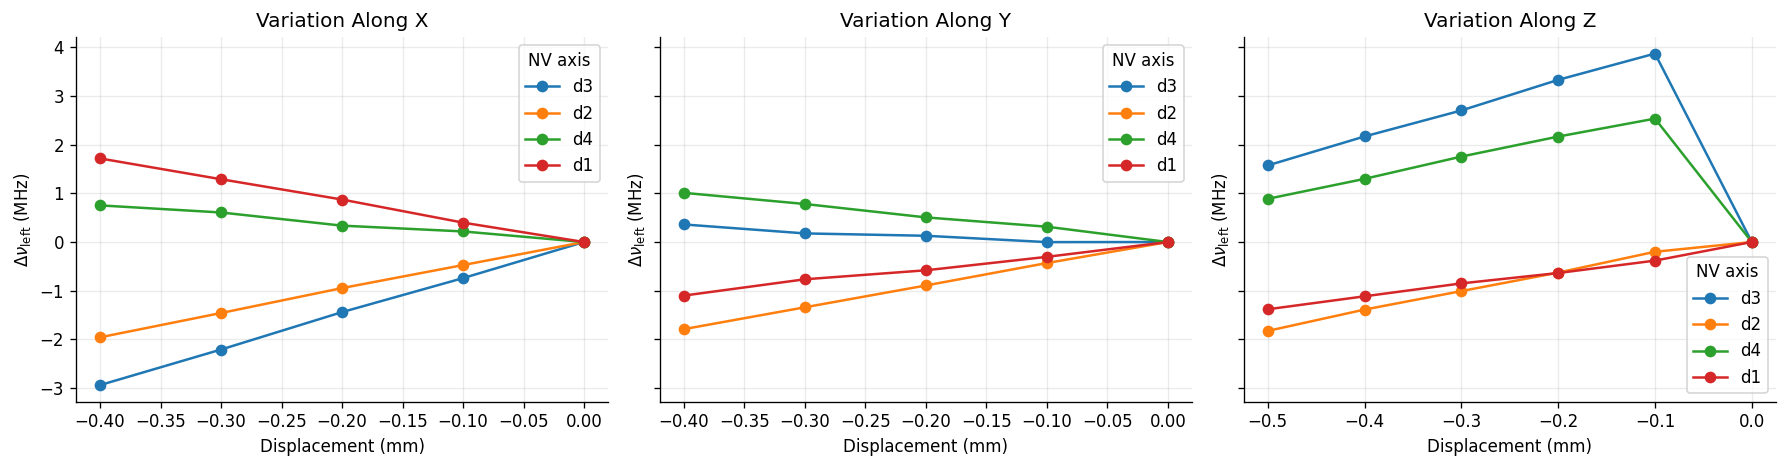

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax_plot, (variation, lab_axis) in zip(axes, VARIATION_TO_AXIS.items()):
    sub = left_lines_long[left_lines_long["variation"] == variation]

    for nv_axis in LEFT_DIP_ORDER:
        d = sub[sub["nv_axis"] == nv_axis].sort_values("offset_mm")
        ax_plot.plot(d["offset_mm"], d["delta_nu_left_MHz"], marker="o", label=nv_axis)

    ax_plot.set_title(variation)
    ax_plot.set_xlabel("Displacement (mm)")
    ax_plot.set_ylabel(r"$\Delta \nu_{\mathrm{left}}$ (MHz)")
    ax_plot.legend(title="NV axis")

plt.tight_layout()
plt.savefig(OUTDIR / "left_dip_shifts_vs_displacement.png", bbox_inches="tight")
plt.show()


## Linear fits and measured response matrix

For each left ODMR line \(i\) and each scan axis \(j\), we fit
\[
\Delta \nu_i(\Delta r_j)\approx b_{ij}+R_{ij}\,\Delta r_j,
\]
so that
\[
R_{ij}=\frac{\partial \nu_i}{\partial r_j}.
\]

This gives the measured \(4\times3\) response matrix \(R_{\mathrm{disp}}\) in units of MHz/mm.


In [5]:
def fit_line_slope(df_axis_line: pd.DataFrame, max_abs_offset_mm=None) -> dict:
    d = df_axis_line.sort_values("offset_mm").copy()

    if max_abs_offset_mm is not None:
        d = d[np.abs(d["offset_mm"]) <= max_abs_offset_mm].copy()

    x = d["offset_mm"].to_numpy(dtype=float)
    y = d["delta_nu_left_MHz"].to_numpy(dtype=float)

    if len(d) < 2:
        raise ValueError("Need at least two points for a linear fit.")

    fit = linregress(x, y)

    return {
        "n_points": len(d),
        "offset_min_mm": float(np.min(x)),
        "offset_max_mm": float(np.max(x)),
        "slope_MHz_per_mm": float(fit.slope),
        "intercept_MHz": float(fit.intercept),
        "r_value": float(fit.rvalue),
        "r_squared": float(fit.rvalue**2),
        "p_value": float(fit.pvalue),
        "slope_stderr": float(fit.stderr),
        "intercept_stderr": float(getattr(fit, "intercept_stderr", np.nan)),
    }

slope_rows = []
for variation, lab_axis in VARIATION_TO_AXIS.items():
    sub_var = left_lines_long[left_lines_long["variation"] == variation]
    for nv_axis in LEFT_DIP_ORDER:
        sub_line = sub_var[sub_var["nv_axis"] == nv_axis]
        fit_res = fit_line_slope(sub_line, max_abs_offset_mm=None)
        slope_rows.append({
            "variation": variation,
            "lab_axis": lab_axis,
            "nv_axis": nv_axis,
            **fit_res,
        })

slopes_df = pd.DataFrame(slope_rows).sort_values(["nv_axis", "lab_axis"]).reset_index(drop=True)
display(slopes_df)

R_disp = (
    slopes_df.pivot(index="nv_axis", columns="lab_axis", values="slope_MHz_per_mm")
    .reindex(index=LEFT_DIP_ORDER, columns=["x", "y", "z"])
)

R_disp_err = (
    slopes_df.pivot(index="nv_axis", columns="lab_axis", values="slope_stderr")
    .reindex(index=LEFT_DIP_ORDER, columns=["x", "y", "z"])
)

print("Measured displacement-response matrix R_disp [MHz/mm]:")
display(R_disp)

print("Slope standard errors [MHz/mm]:")
display(R_disp_err)


,variation,lab_axis,nv_axis,n_points,offset_min_mm,offset_max_mm,slope_MHz_per_mm,intercept_MHz,r_value,r_squared,p_value,slope_stderr,intercept_stderr
0,Variation Along X,x,d1,5,-0.4,0.0,-4.326350,-0.009361,-0.999735,0.999469,5.188155e-06,0.057552,0.014097
1,Variation Along Y,y,d1,5,-0.4,0.0,2.661309,-0.017761,0.996807,0.993625,2.164529e-04,0.123075,0.030147
2,Variation Along Z,z,d1,6,-0.5,0.0,2.662852,-0.061632,0.996445,0.992903,1.893290e-05,0.112565,0.034081
3,Variation Along X,x,d2,5,-0.4,0.0,4.899925,0.012820,0.999849,0.999697,2.237149e-06,0.049240,0.012061
4,Variation Along Y,y,d2,5,-0.4,0.0,4.487572,0.006756,0.999960,0.999920,3.023669e-07,0.023141,0.005668
5,Variation Along Z,z,d2,6,-0.5,0.0,3.734428,0.092159,0.996130,0.992274,2.244129e-05,0.164760,0.049884
6,Variation Along X,x,d3,5,-0.4,0.0,7.345295,0.003166,0.999920,0.999840,8.617926e-07,0.053705,0.013155
7,Variation Along Y,y,d3,5,-0.4,0.0,-0.900987,-0.047207,-0.950649,0.903734,1.306268e-02,0.169775,0.041586
8,Variation Along Z,z,d3,6,-0.5,0.0,-0.610088,2.122585,-0.082681,0.006836,8.762605e-01,3.676760,1.113194
9,Variation Along X,x,d4,5,-0.4,0.0,-1.895183,0.003851,-0.994452,0.988934,4.957017e-04,0.115745,0.028352


Measured displacement-response matrix R_disp [MHz/mm]:


lab_axis,x,y,z
nv_axis,,,
d3,7.345295,-0.900987,-0.610088
d2,4.899925,4.487572,3.734428
d4,-1.895183,-2.487449,-0.090480
d1,-4.326350,2.661309,2.662852


Slope standard errors [MHz/mm]:


lab_axis,x,y,z
nv_axis,,,
d3,0.053705,0.169775,3.676760
d2,0.049240,0.023141,0.164760
d4,0.115745,0.095998,2.456798
d1,0.057552,0.123075,0.112565


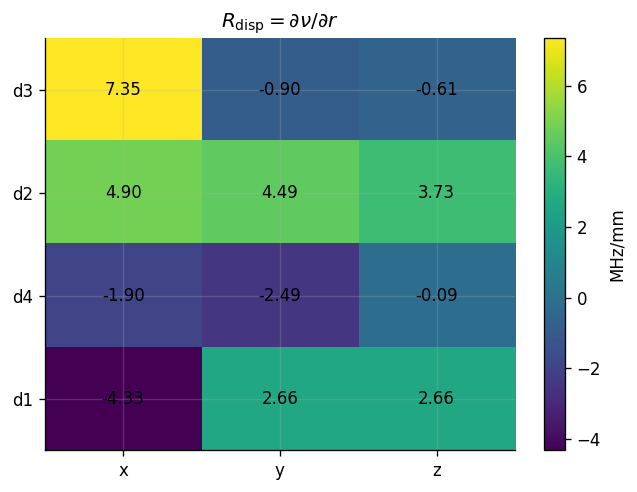

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))
im = ax.imshow(R_disp.to_numpy(dtype=float), aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["x", "y", "z"])
ax.set_yticks(range(4))
ax.set_yticklabels(LEFT_DIP_ORDER)
ax.set_title(r"$R_{\mathrm{disp}} = \partial \nu / \partial r$")

for i in range(R_disp.shape[0]):
    for j in range(R_disp.shape[1]):
        val = R_disp.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="MHz/mm")
plt.tight_layout()
plt.savefig(OUTDIR / "R_disp_heatmap.png", bbox_inches="tight")
plt.show()


## [100]-cut geometry and fixed NV-axis set

For a [100]-cut diamond with lab \(z\) along the surface normal / optical axis, a convenient tetrahedral NV-axis template is
\[
\begin{aligned}
d3 &= \left(+\sqrt{\tfrac23},\,0,\,+\tfrac{1}{\sqrt3}\right),\\
d4 &= \left(-\sqrt{\tfrac23},\,0,\,+\tfrac{1}{\sqrt3}\right),\\
d2 &= \left(0,\,+\sqrt{\tfrac23},\,-\tfrac{1}{\sqrt3}\right),\\
d1 &= \left(0,\,-\sqrt{\tfrac23},\,-\tfrac{1}{\sqrt3}\right).
\end{aligned}
\]

This enforces the geometry you specified: two orientations above the plane \((d3,d4)\) and two below \((d1,d2)\).


In [8]:
a = np.sqrt(2/3)
b = 1/np.sqrt(3)

NV_AXES_LAB = {
    "d3": np.array([+a,  0.0, +b]),
    "d2": np.array([ 0.0, +a, -b]),
    "d4": np.array([-a,  0.0, +b]),
    "d1": np.array([ 0.0, -a, -b]),
}

N_lab = np.vstack([NV_AXES_LAB[k] for k in LEFT_DIP_ORDER])

display(pd.DataFrame(N_lab, index=LEFT_DIP_ORDER, columns=["lab_x", "lab_y", "lab_z"]))


,lab_x,lab_y,lab_z
d3,0.816497,0.000000,0.57735
d2,0.000000,0.816497,-0.57735
d4,-0.816497,0.000000,0.57735
d1,0.000000,-0.816497,-0.57735


## Estimate the bias field Bo from the reference spectrum

At the chosen zero-offset operating point, the four splittings give the four projected-field magnitudes
\[
|n_i\cdot B_0| \approx \frac{\Delta \nu_i}{2\gamma_e}.
\]


## Numerical Hamiltonian fit and numerical \(A\)

We now refine the bias field by fitting the full spin-1 Hamiltonian to the **eight** measured line centers of the reference spectrum.

For each NV orientation \(i\), we use
\[
H_i/h = (D+M_{z,i})S_z^2 + \gamma_e\,\mathbf B_i\cdot \mathbf S,
\]
with \(D\) from the chosen reference run and \(M_{z,i}\) from the fitted pair centers:
\[
M_{z,i} = \nu_{c,i} - D.
\]

The lower transition is the measured **left** line and the upper transition is the measured **right** line.  
Finally, we compute
\[
A_{ij}=\frac{\partial \nu_i}{\partial B_j}
\]
numerically by finite differences around the fitted \(B_0\).
